# Tutorial 01 · First Readout, Conductance Peak, and Noise

In this notebook, we will:

1. define a minimal dot-sensor system
2. inspect the Coulomb-peak and chosen operating point
3. simulate one noiseless readout trace
4. add `1/f` and OU noise on top of the same setup
5. compare raw traces, integrated traces, and their evolution in the IQ-plane



## Readout Roadmap

Before going into the details, it helps to keep the full signal chain in mind:

1. choose a charge state
2. convert that state into an effective detuning shift
3. place that shift on the Coulomb peak
4. simulate the reflected readout trace
5. demodulate to `I/Q`
6. integrate over the measurement time



In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation, PillowWriter

repo_root = Path.cwd().parent if Path.cwd().name == 'tutorials' else Path.cwd()
sys.path.append(str(repo_root / 'src'))

from readout_simulator import QuantumDotSystem, RLC_sensor, integrate_iq_traces
from readout_simulator.helper_functions import demo_ou_noise, plot_coulomb_peak_minimal
from readout_simulator.noise_models import SpectrumNoise

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 125,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.color': '#cbd5e1',
    'axes.facecolor': '#fcfcfe',
})



## 1. Define the Electrostatic System

A `QuantumDotSystem` is defined by two capacitance objects:

- `Cdd`: dot-dot capacitance matrix
- `Cds`: dot-sensor capacitance matrix

For this one-dot tutorial, both are `1 x 1` arrays.

We define two states even in this first tutorial:

- `[0]` as an empty reference state
- `[1]` as the occupied state we will read out

That lets us visualise where the two states sit on the conductance peak before we simulate a time trace.



In [ ]:
dot_system = QuantumDotSystem(
    Cdd=np.array([[1.0]]),
    Cds=np.array([[0.1]]),
)

charge_state_ref = np.array([0]) # reference state
charge_state = np.array([1]) # occupied state

print('Chosen charge states:', charge_state_ref, 'and', charge_state)
print('Effective coupling matrix:', dot_system.get_coupling_matrix())


Chosen charge states: [0] and [1]
Effective coupling matrix: [[0.1]]


## 2. Define the Resonator Sensor

An `RLC_sensor` combines:

- **resonator parameters** such as inductance and parasitic capacitance
- **Coulomb-peak parameters** controlling how sensor conductance depends on energy offset

In practice:

- `Lc`, `Cp`, `RL`, `Rc`, `Z0` define the resonator and its coupling
- `g0`, `eps0`, `eps_width` define the conductance peak seen by the sensor

The most important readout choice is often the **operating point** `eps0`.
If the operating point lies on a steep flank of the Coulomb peak, small detuning shifts create larger conductance changes, and, therefore, a better distinction between states.



In [16]:
resonator_params = {
    'Lc': 800e-9,
    'Cp': 0.5e-12,
    'RL': 40,
    'Rc': 0.0,
    'Z0': 50,
}

coulomb_peak_params = {
    'g0': 1/50,
    'eps0': 0.45,
    'eps_width': 1.0,
}

sensor = RLC_sensor(resonator_params, coulomb_peak_params)

times = np.arange(0, 1.4e-6, 1e-9)
dt = times[1] - times[0]
times_ns = 1e9 * times

print('---------------------------')
print('Time samples:', len(times))
print('Readout duration: %.1f ns' % times_ns[-1])
print('Sensor resonance f0 = %.3e Hz' % sensor.f0)



[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 0.000e+00 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: None
  Energy noise model: None
---------------------------
Time samples: 1400
Readout duration: 1399.0 ns
Sensor resonance f0 = 2.516e+08 Hz


## 3. Inspect the Coulomb Peak Before Simulating

The occupied and empty charge states shift the effective detuning seen by the sensor, and the conductance peak turns that detuning shift into a measurable conductance contrast.



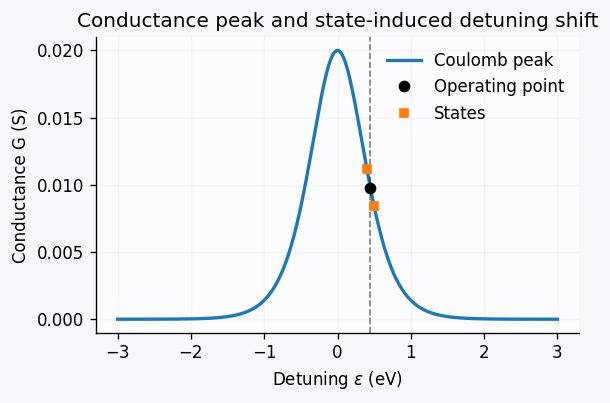

Empty-state offset   = 0.000e+00 eV
Occupied-state offset = 1.000e-01 eV
State separation on epsilon axis = 1.000e-01 eV


In [17]:
offset_ref = dot_system.get_energy_offset(charge_state_ref, np.array([0.0]), eps0=0.0)[0]
offset_occ = dot_system.get_energy_offset(charge_state, np.array([0.0]), eps0=0.0)[0]
delta_eps = abs(offset_occ - offset_ref)

fig, ax = plt.subplots(figsize=(5.2, 3.2), dpi=120)
fig.patch.set_facecolor('#f7f7fb')
plot_coulomb_peak_minimal(coulomb_peak_params, delta_eps=delta_eps, ax=ax)
ax.set_title('Conductance peak and state-induced detuning shift', fontsize=12)
plt.show()

print(f'Empty-state offset   = {offset_ref:.3e} eV')
print(f'Occupied-state offset = {offset_occ:.3e} eV')
print(f'State separation on epsilon axis = {delta_eps:.3e} eV')



## 4. Simulate the Noiseless Readout Trace

We now simulate **both charge states** on the same sensor:

- `State [0]`: empty reference state
- `State [1]`: occupied state

`sensor.get_signal(...)` returns:

- `I`: demodulated in-phase quadrature
- `Q`: demodulated quadrature-phase signal
- `V_refl`: reflected voltage trace
- `summary`: a small dictionary of auxiliary information


In [21]:
state_definitions = {
    'State [0]': charge_state_ref,
    'State [1]': charge_state,
}
state_colours = {
    'State [0]': '#2563EB',
    'State [1]': '#DC2626',
}

noiseless_signals = {}
for state_label, state_vector in state_definitions.items():
    I_state, Q_state, V_state, summary_state = sensor.get_signal(
        times=times,
        dot_system=dot_system,
        charge_state=state_vector,
        sensor_index=0,
        params={'eps0': 0.0},
        use_stationary_initial_state=True,
    )

    I_state_int, Q_state_int = integrate_iq_traces(
        I_state[np.newaxis, :],
        Q_state[np.newaxis, :],
        axis=-1,
    )

    noiseless_signals[state_label] = {
        'charge_state': state_vector.copy(),
        'I': I_state,
        'Q': Q_state,
        'V_refl': V_state,
        'I_int': I_state_int[0],
        'Q_int': Q_state_int[0],
        'summary': summary_state,
    }

state_summaries = {
    label: {
        'charge_state': payload['charge_state'].tolist(),
        'mean_I': float(np.mean(payload['I'])),
        'mean_Q': float(np.mean(payload['Q'])),
    }
    for label, payload in noiseless_signals.items()
}

state_summaries

{'State [0]': {'charge_state': [0],
  'mean_I': 0.03921686703804713,
  'mean_Q': -0.49643283743614447},
 'State [1]': {'charge_state': [1],
  'mean_I': 0.03921384996615057,
  'mean_Q': -0.4964008804895572}}

## 5. Parameter Summary

This compact view makes clear **which quantities are user-defined** and **which are derived from the simulator**.



In [6]:
print('--- Resonator parameters ---')
for key, value in resonator_params.items():
    print(f'{key:>4s} = {value}')

print('\n--- Coulomb-peak parameters ---')
for key, value in coulomb_peak_params.items():
    print(f'{key:>9s} = {value}')

print('\n--- Derived sensor values ---')
print(f'f0 = {sensor.f0:.3e} Hz')
print(f'T0 = {sensor.T0:.3e} s')
print(f'eps_w = {sensor.eps_w:.3e} eV')
print(f'Number of time samples = {len(times)}')



--- Resonator parameters ---
  Lc = 8e-07
  Cp = 5e-13
  RL = 40
  Rc = 0.0
  Z0 = 50

--- Coulomb-peak parameters ---
       g0 = 0.02
     eps0 = 0.45
eps_width = 1.0

--- Derived sensor values ---
f0 = 2.516e+08 Hz
T0 = 3.974e-09 s
eps_w = 1.000e+00 eV
Number of time samples = 1400


## 6. Visualise the Noiseless Output

The first figure overlays the two charge states so you can see the readout contrast directly.
Each panel shows the same sensor under the same resonator settings; only the charge state changes.

We compare:

- the demodulated `I` trace
- the demodulated `Q` trace
- the running-average integrated `I` trace
- the running-average integrated `Q` trace


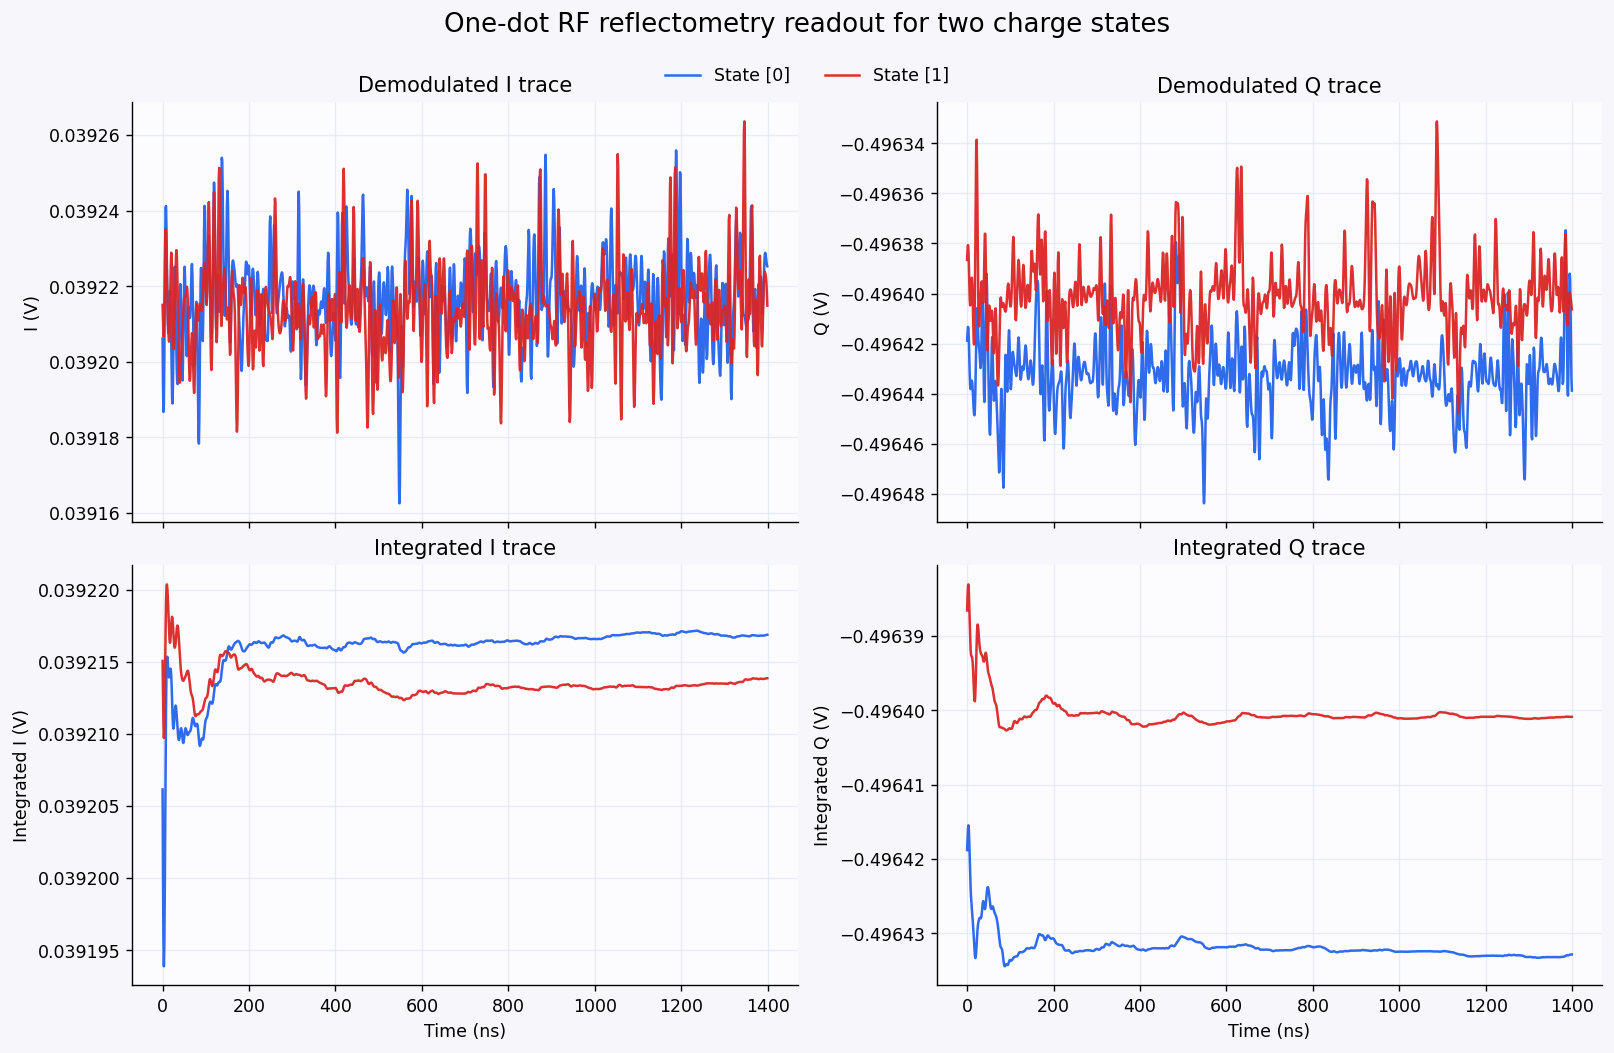

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12.8, 7.8), constrained_layout=True, sharex=True)
fig.patch.set_facecolor('#f7f7fb')

for state_label, payload in noiseless_signals.items():
    colour = state_colours[state_label]

    axes[0, 0].plot(times_ns, payload['I'], color=colour, lw=1.45, alpha=0.95, label=state_label)
    axes[0, 1].plot(times_ns, payload['Q'], color=colour, lw=1.45, alpha=0.95, label=state_label)
    axes[1, 0].plot(times_ns, payload['I_int'], color=colour, lw=1.45, alpha=0.95, label=state_label)
    axes[1, 1].plot(times_ns, payload['Q_int'], color=colour, lw=1.45, alpha=0.95, label=state_label)

axes[0, 0].set_title('Demodulated I trace', fontsize=12)
axes[0, 0].set_ylabel('I (V)')

axes[0, 1].set_title('Demodulated Q trace', fontsize=12)
axes[0, 1].set_ylabel('Q (V)')

axes[1, 0].set_title('Integrated I trace', fontsize=12)
axes[1, 0].set_xlabel('Time (ns)')
axes[1, 0].set_ylabel('Integrated I (V)')

axes[1, 1].set_title('Integrated Q trace', fontsize=12)
axes[1, 1].set_xlabel('Time (ns)')
axes[1, 1].set_ylabel('Integrated Q (V)')

for ax in axes.ravel():
    ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('One-dot RF reflectometry readout for two charge states', fontsize=15, y=1.06)
plt.show()


### What To Notice

- The two states already separate in the raw `I` and `Q` traces, even before any explicit noise is added.
- The integrated traces are smoother than the instantaneous traces, which is why time integration is useful for readout.
- This noiseless view is the clean baseline to compare against once `1/f` and OU noise are introduced.


## 7. Add Detuning Noise: `1/f` and OU

We now keep the same dot system and the same sensor, but perturb the detuning trajectory.
The **same noise realisation** is applied to both states in each column, so any separation you see still comes from the charge state itself.

We use:

- `SpectrumNoise` to generate a `1/f` trajectory
- `demo_ou_noise(...)` to generate a correlated OU trajectory

Additional implemented noise tools also exist in the repository:

- `OverFNoise` for a JAX-oriented fluctuator construction of `1/f` noise
- `CorrelatedNoise` for correlated multi-sensor noise generation

Those are useful later when moving toward larger simulations.


In [22]:
def psd_1f(freq):
    return np.where(freq > 0, 1 / freq, 0.0)

noise_1f_model = SpectrumNoise(psd_func=psd_1f, sigma=0.18)
noise_1f = noise_1f_model.generate_trajectory(times, seed=7)

_, noise_ou = demo_ou_noise(
    T=times[-1] + dt,
    dt=dt,
    sigma=0.12,
    tau=120e-9,
    rng=np.random.default_rng(9),
)
noise_ou = noise_ou[:len(times)]

noise_cases = {
    'Noiseless': np.zeros_like(times),
    '1/f noise': noise_1f,
    'OU noise': noise_ou,
}
case_titles = ['Noiseless', '1/f noise', 'OU noise']

signals = {}
for label, noise_traj in noise_cases.items():
    state_payloads = {}

    for state_label, state_vector in state_definitions.items():
        I_case, Q_case, V_case, summary_case = sensor.get_signal(
            times=times,
            dot_system=dot_system,
            charge_state=state_vector,
            sensor_index=0,
            noise_trajectory=noise_traj if label != 'Noiseless' else None,
            params={'eps0': 0.0},
            use_stationary_initial_state=True,
        )

        I_case_int, Q_case_int = integrate_iq_traces(
            I_case[np.newaxis, :],
            Q_case[np.newaxis, :],
            axis=-1,
        )

        state_payloads[state_label] = {
            'charge_state': state_vector.copy(),
            'I': I_case,
            'Q': Q_case,
            'I_int': I_case_int[0],
            'Q_int': Q_case_int[0],
            'V_refl': V_case,
            'summary': summary_case,
        }

    signals[label] = {
        'noise': noise_traj,
        'states': state_payloads,
    }


C:\Users\rouvenkoch\AppData\Local\Temp\ipykernel_13016\645014280.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.where(freq > 0, 1 / freq, 0.0)


## 8. Compare How the Same Readout Changes Under Noise

The next figure keeps the layout identical across columns.
Only the detuning trajectory changes, while both charge states are shown in each panel.
This makes it easy to see:

- how each noise model perturbs the sensor in time
- how the demodulated `I` and `Q` traces separate for the two states
- how the integrated signal evolves when realistic noise is added


### What To Notice

- Each column uses the same sensor and the same pair of charge states; only the detuning trajectory changes.
- The noisy cases broaden the two-state traces, but the state-dependent separation is still visible.
- Sharing the same noise realisation across states makes it easier to isolate which changes come from noise and which come from the charge state itself.


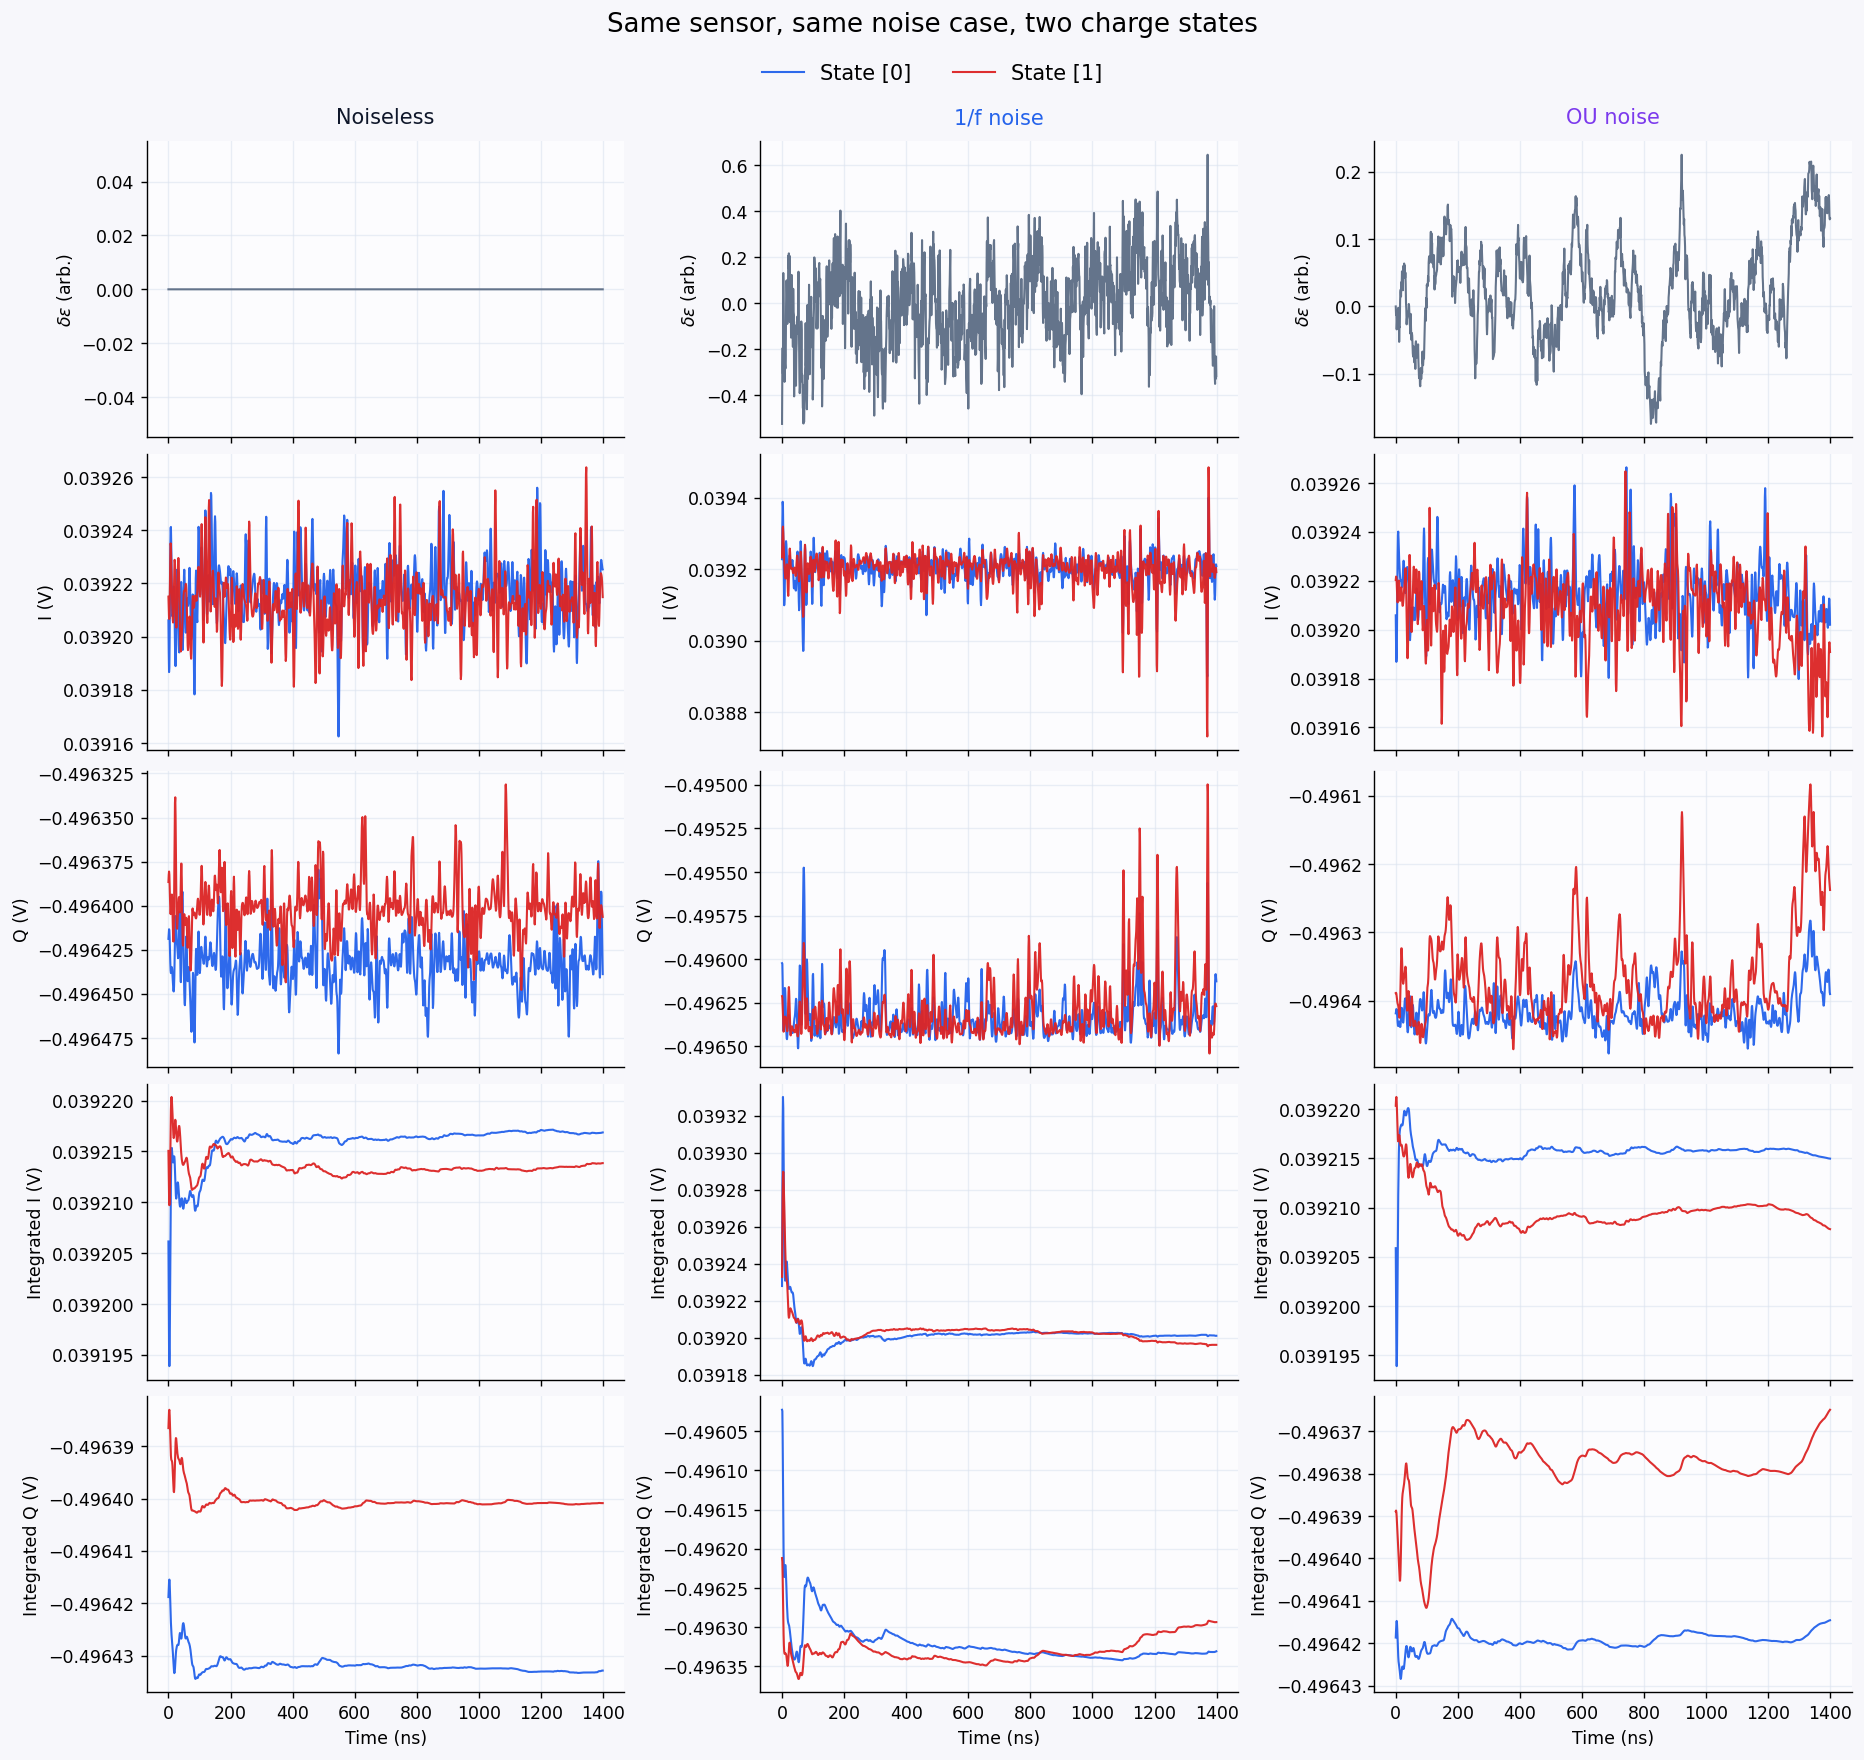

In [30]:
fig, axes = plt.subplots(5, 3, figsize=(14.8, 13.2), constrained_layout=True, sharex='col')
fig.patch.set_facecolor('#f7f7fb')

title_colors = ['#0F172A', '#2563EB', '#7C3AED']

for col_idx, label in enumerate(case_titles):
    payload = signals[label]
    axes[0, col_idx].plot(times_ns, payload['noise'], color='#64748B', lw=1.2)
    axes[0, col_idx].set_title(label, fontsize=12, color=title_colors[col_idx], pad=10)
    axes[0, col_idx].set_ylabel('$\\delta \\epsilon$ (arb.)')

    for state_label, state_payload in payload['states'].items():
        colour = state_colours[state_label]
        axes[1, col_idx].plot(times_ns, state_payload['I'], color=colour, lw=1.2, alpha=0.96, label=state_label)
        axes[2, col_idx].plot(times_ns, state_payload['Q'], color=colour, lw=1.2, alpha=0.96, label=state_label)
        axes[3, col_idx].plot(times_ns, state_payload['I_int'], color=colour, lw=1.2, alpha=0.96, label=state_label)
        axes[4, col_idx].plot(times_ns, state_payload['Q_int'], color=colour, lw=1.2, alpha=0.96, label=state_label)

    axes[1, col_idx].set_ylabel('I (V)')
    axes[2, col_idx].set_ylabel('Q (V)')
    axes[3, col_idx].set_ylabel('Integrated I (V)')
    axes[4, col_idx].set_xlabel('Time (ns)')
    axes[4, col_idx].set_ylabel('Integrated Q (V)')

for ax in axes.ravel():
    ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)

handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.035), fontsize=12)
fig.suptitle('Same sensor, same noise case, two charge states', fontsize=15, y=1.055)
plt.show()


## 9. Integrated IQ Convergence Under Different Noise Models

A useful final comparison is to look at the integrated trajectory directly in the IQ plane.
Here we again keep both charge states in view, so each panel shows how the two-state readout cluster forms over time under a given noise model.


### What To Notice

- In IQ space, the two states form separate (integrated) trajectories 
- The final integrated point is often much more stable than the raw trace suggests
- This is the key reason integrated `I/Q` is such a useful readout representation (also later for dataset generation and classification tasks)


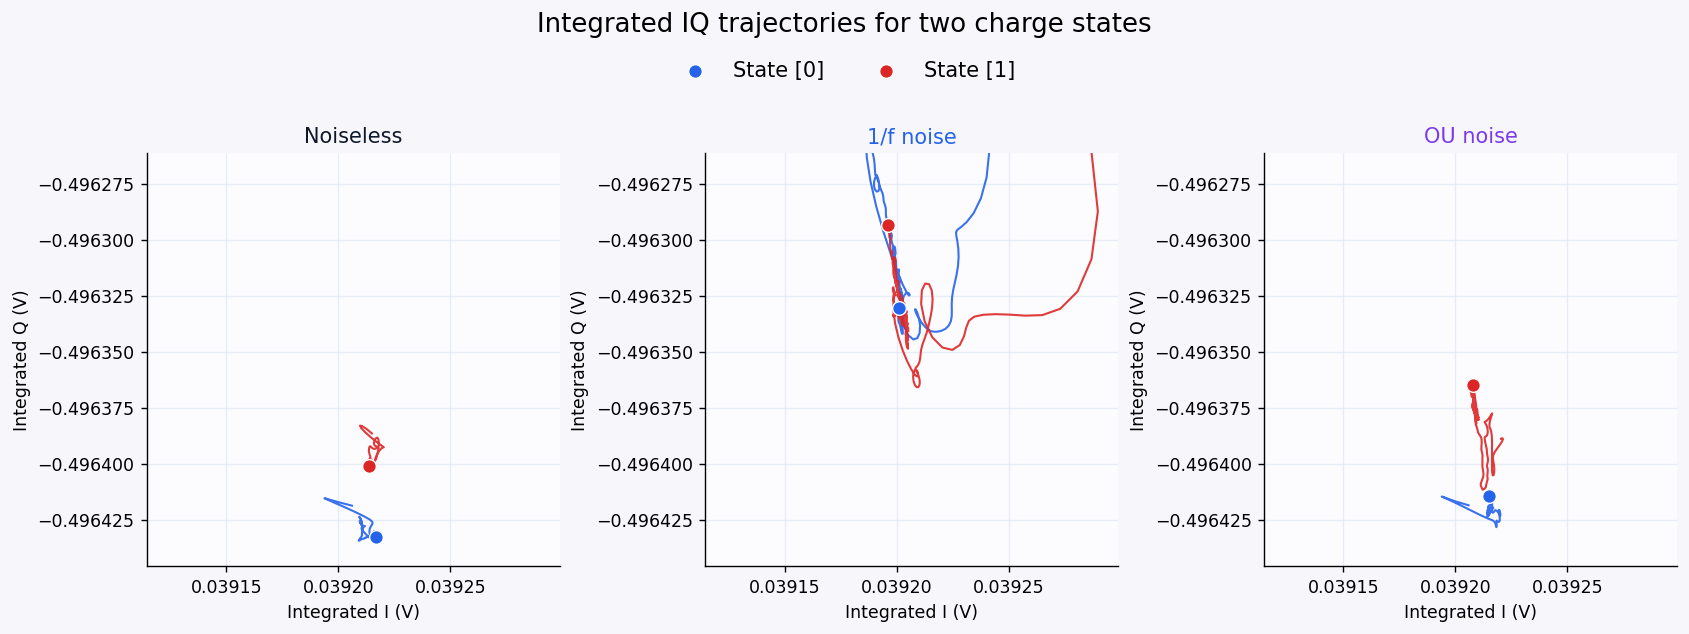

In [31]:
all_i_int = np.concatenate([
    signals[label]['states'][state_label]['I_int']
    for label in case_titles
    for state_label in state_definitions
])
all_q_int = np.concatenate([
    signals[label]['states'][state_label]['Q_int']
    for label in case_titles
    for state_label in state_definitions
])

x_lo, x_hi = np.quantile(all_i_int, [0.01, 0.99])
y_lo, y_hi = np.quantile(all_q_int, [0.01, 0.99])
x_center = 0.5 * (x_lo + x_hi)
y_center = 0.5 * (y_lo + y_hi)
half_span = 0.58 * max(x_hi - x_lo, y_hi - y_lo)
half_span = max(half_span, 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.8), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')

for ax, label, title_colour in zip(axes, case_titles, ['#0F172A', '#2563EB', '#7C3AED']):
    ax.set_facecolor('#fcfcfe')
    for state_label, state_payload in signals[label]['states'].items():
        colour = state_colours[state_label]
        ax.plot(state_payload['I_int'], state_payload['Q_int'], color=colour, lw=1.2, alpha=0.9)
        ax.scatter(
            state_payload['I_int'][-1],
            state_payload['Q_int'][-1],
            s=62,
            color=colour,
            edgecolor='white',
            linewidth=0.8,
            zorder=3,
            label=state_label,
        )

    ax.set_title(label, fontsize=12, color=title_colour)
    ax.set_xlabel('Integrated I (V)')
    ax.set_ylabel('Integrated Q (V)')
    ax.set_xlim(x_center - half_span, x_center + half_span)
    ax.set_ylim(y_center - half_span, y_center + half_span)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03), fontsize=12)
fig.suptitle('Integrated IQ trajectories for two charge states', fontsize=15, y=1.08)
plt.show()


In [11]:
gif_output = repo_root / 'tutorials' / 'assets'
gif_output.mkdir(parents=True, exist_ok=True)
gif_path = gif_output / 'tutorial_01_integrated_iq_convergence.gif'

frame_idx = np.unique(np.linspace(0, len(times_ns) - 1, 120).astype(int))

fig, axes = plt.subplots(1, 3, figsize=(13.4, 5.2), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')

def draw_frame(frame_number):
    idx = frame_idx[frame_number]
    current_time = times_ns[idx]

    for ax, label, title_colour in zip(axes, case_titles, ['#0F172A', '#2563EB', '#7C3AED']):
        ax.clear()
        ax.set_facecolor('#fcfcfe')

        for state_label, state_payload in signals[label]['states'].items():
            colour = state_colours[state_label]
            i_path = state_payload['I_int'][:idx + 1]
            q_path = state_payload['Q_int'][:idx + 1]

            ax.plot(i_path, q_path, color=colour, lw=1.15, alpha=0.9)
            ax.scatter(
                state_payload['I_int'][idx],
                state_payload['Q_int'][idx],
                s=68,
                color=colour,
                edgecolor='#111827',
                linewidth=0.8,
                zorder=4,
                label=state_label,
            )

        ax.set_title(label, fontsize=12, color=title_colour)
        ax.set_xlabel('Integrated I (V)')
        ax.set_ylabel('Integrated Q (V)')
        ax.set_xlim(x_center - half_span, x_center + half_span)
        ax.set_ylim(y_center - half_span, y_center + half_span)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)

    axes[0].legend(frameon=False, loc='upper left')
    fig.suptitle(
        f'Integrated IQ convergence for two charge states | t = {current_time:.0f} ns',
        fontsize=15,
    )

animation = FuncAnimation(fig, draw_frame, frames=len(frame_idx), interval=70, blit=False)
animation.save(gif_path, writer=PillowWriter(fps=18))
plt.close(fig)


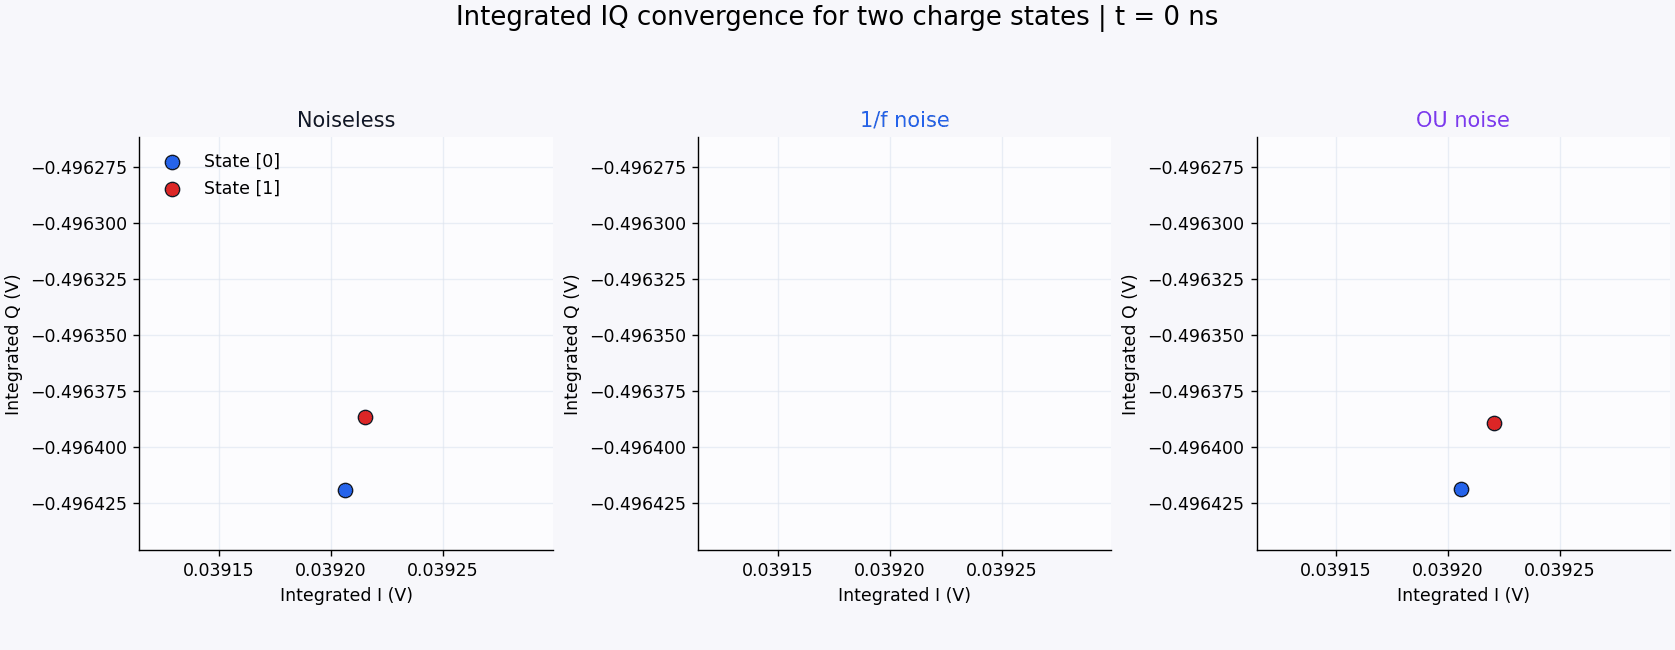

In [12]:
display(Image(filename=str(gif_path)))



## Takeaway

- `QuantumDotSystem` defines the electrostatics; `RLC_sensor` defines the resonator and Coulomb-peak response.
- The conductance-peak plot is the quickest way to understand **why** the readout is sensitive to a chosen charge transition.
- Simulating both `State [0]` and `State [1]` makes the charge-state contrast visible immediately in both the raw and integrated traces.
- The noiseless case is useful for orientation, but `1/f` and OU noise show how realistic detuning fluctuations broaden the readout.
- Integration helps because it smooths the readout point over time, even when the instantaneous trajectory wanders.
